In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import numpy as np

def precision(y_true, y_pred, normalize=True, sample_weight=None):
    pre_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_prec = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_prec = 1
            pre_list.append(tmp_prec)
        elif len(set_pred) > 0:
            tmp_prec = len(set_true.intersection(set_pred))/\
                    float(len(set_pred))
            pre_list.append(tmp_prec)
        else:
            None
    return np.mean(pre_list)

def recall(y_true, y_pred, normalize=True, sample_weight=None):
    rec_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_rec = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_rec = 1
        else:
            tmp_rec = len(set_true.intersection(set_pred))/\
                    float(len(set_true))
        rec_list.append(tmp_rec)
    return np.mean(rec_list)

def f_score(y_true, y_pred, normalize=True, sample_weight=None):
    acc_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_a = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_a = 1
        else:
            tmp_a = (2*len(set_true.intersection(set_pred)))/\
                    float( len(set_true) + len(set_pred))
        acc_list.append(tmp_a)
    return np.mean(acc_list)

In [ ]:
import math
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from keras import backend as K
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
import keras
tf.random.set_seed(7)

In [ ]:
from csv import writer

def test_segment(filename, low, up):
    myFile = open(filename, 'w', newline = '')
    with myFile:
        csv_writer = writer(myFile)
        for j, row in enumerate(seqData):
            segment = [ ]
            if(len(row) > low and len(row) < up):
                segment.append(row)
                for item in label[j]:
                    segment.append(item)
                csv_writer.writerow(segment)
    myFile.close()

dataframe = pd.read_csv("/content/gdrive/My Drive/Transformer_positional_embedding/CAFA3/bp/test_data_bp1.csv", header=None)
dataset = dataframe.values
seqData = dataset[:,0]
label = dataset[:,1:len(dataset[0])]
print('Original Dataset Size : %s' %len(dataset))
test_segment('testData200.csv', 0, 201)
test_segment('testData500.csv', 200, 501)
test_segment('testData1000.csv', 500, 1001)
test_segment('testData16000.csv', 1000, 16000)

Original Dataset Size : 2392


In [ ]:
def segment(dataset, label, seg_size, overlap, m_len):
    print("Non-overlapping Region: %s" %overlap)
    print("Segment Size: %s" %seg_size)

    seq_data, label_data = [], []
    for j, row in enumerate(dataset):
        if(len(row) < m_len + 1):
            pos = math.ceil(len(row)/overlap)
            if(pos < math.ceil(seg_size/overlap)):
                pos = math.ceil(seg_size/overlap)
            for itr in range(pos - math.ceil(seg_size/overlap) + 1):
                init = itr * overlap
                if(len(row[init : init + seg_size]) > 40):
                    seq_data.append(row[init : init + seg_size])
                    label_data.append(label[j])
    return seq_data, label_data

dataframe = pd.read_csv('/content/gdrive/My Drive/Transformer_positional_embedding/CAFA3/bp/train_data_bp1.csv', header=None)
dataset = dataframe.values
print('Original Dataset Size : %s' %len(dataset))
X = dataset[:,0]
Y = dataset[:,1:len(dataset[0])]
nb_of_cls = len(Y[0])
del dataframe, dataset
print(X.shape, Y.shape)
print(nb_of_cls)

# Preparing For Training
segmentSize = 250
nonOL = segmentSize - 100
SEG = str(segmentSize)

Original Dataset Size : 53500
(53500,) (53500, 3992)
3992


In [ ]:
def dictionary(chunk_size):
    dataframe = pd.read_csv("/content/gdrive/My Drive/Transformer_positional_embedding/CAFA3/bp/train_data_bp1.csv", header=None)
    dataset = dataframe.values
    del dataframe

    seq_dataset = dataset[:,0]
    print('Creating Dictionary:')
    dict = {}
    j = 0
    for row in seq_dataset:
        for i in range(len(row) - chunk_size + 1):
            key = row[i:i + chunk_size]
            if key not in dict:
                dict[key] = j
                j = j + 1
    del dataset, seq_dataset
    return(dict)

def nGram(dataset, chunk_size, dictI):
    dict1 = list()
    for j, row in enumerate(dataset):
        string = row
        dict2 = list()
        for i in range(len(string) - chunk_size + 1):
            try:
                dict2.append(dictI[string[i:i + chunk_size]])
            except:
                None
        dict1.append(dict2)
    return(dict1)

# CREATING DICTIONARY
chunkSize = 4
dict_Prop = dictionary(chunkSize)
max_seq_len = segmentSize - chunkSize + 1

Creating Dictionary:


In [ ]:
def scaledSoftmax(x, axis=-1):
    ndim = keras.ops.ndim(x)
    if ndim == 2:
        s = keras.ops.softmax(x)
        m = keras.ops.max(s, axis = -1, keepdims=True)
        p = s/m
        return 1*p
    else:
        raise ValueError('Cannot apply softmax to a tensor that is 1D')

def DC_CNN_Block(nb_filter, filter_length, dilation, l2_layer_reg):
    def f(input_):
        residual = input_
        layer_out = layers.Conv1D(filters=nb_filter, kernel_size=filter_length, dilation_rate=dilation,
                                  activation='linear', padding='same', use_bias=True)(input_)
        layer_out = layers.BatchNormalization(epsilon=1.1e-5)(layer_out)
        layer_out = layers.Activation("gelu")(layer_out)
        return layer_out
    return f

embed_dim = 64
ff_dim = 960

def DC_CNN_Model(top_words, seq_len, o_dim):
    f_num = 192
    f_size = [6,6,6,6,6]

    _input = layers.Input(shape=(seq_len,))
    emd = layers.Embedding(top_words, embed_dim, input_length = seq_len)(_input)
    drop1 = layers.Dropout(0.3)(emd)

    l1 = DC_CNN_Block(f_num, f_size[0], 1, 0.001)(drop1)
    l2 = DC_CNN_Block(f_num, f_size[1], 3, 0.001)(drop1)
    l3 = DC_CNN_Block(f_num, f_size[2], 5, 0.001)(drop1)
    l4 = DC_CNN_Block(f_num, f_size[3], 7, 0.001)(drop1)
    l5 = DC_CNN_Block(f_num, f_size[4], 9, 0.001)(drop1)

    x = layers.Concatenate(axis = -1)([l1, l2, l3, l4, l5])

    sent_representation = layers.GlobalAveragePooling1D()(x)
    #sent_representation = layers.Lambda(lambda xin: keras.ops.sum(xin, axis=1))(sent_representation)

    x = layers.Dropout(0.4)(sent_representation)
    _output = layers.Dense(o_dim, kernel_initializer='normal', activation='sigmoid', name='CLASSIFIER')(x)

    model = keras.Model(inputs=_input, outputs=_output)
    model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                  optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005),
                  metrics = [tf.keras.metrics.BinaryAccuracy(threshold=0.5)])
    return model

# Create & Compile the model
model = DC_CNN_Model(len(dict_Prop), max_seq_len, nb_of_cls)
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 247)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 247, 64)   │ 10,303,552 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 247, 64)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 247, 192)  │     73,920 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 247, 192)  │     73,920 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 247, 192)  │     73,920 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 247, 192)  │     73,920 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 247, 192)  │     73,920 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 247, 192)  │        768 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 247, 192)  │        768 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 247, 192)  │        768 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 247, 192)  │        768 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 247, 192)  │        768 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 247, 192)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 247, 192)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 247, 192)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 247, 192)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 247, 192)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 247, 960)  │          0 │ activation[0][0]

 Total params: 14,513,304 (55.36 MB)

 Trainable params: 14,511,384 (55.36 MB)

 Non-trainable params: 1,920 (7.50 KB)

None


In [ ]:
div = [200, 500, 1000, 2000]
for max_len in div:
    X1, Y1 = segment(X, Y, segmentSize, nonOL, max_len)

    #Split the dataset
    x_tr, x_val, y_tr, y_val = train_test_split(X1, Y1, test_size = 0.1, random_state = 42)
    del X1, Y1

    y_train = np.array(y_tr, dtype=None)
    y_validate = np.array(y_val, dtype=None)
    print(len(x_tr), len(x_val))
    print(y_train.shape, y_validate.shape)

    del y_tr, y_val

    #CREATING N-GRAM
    x_train = nGram(x_tr, chunkSize, dict_Prop)
    x_validate = nGram(x_val, chunkSize, dict_Prop)
    del x_tr, x_val

    # truncate and pad input sequences
    x_train = sequence.pad_sequences(x_train, maxlen=max_seq_len)
    x_validate = sequence.pad_sequences(x_validate, maxlen=max_seq_len)

    # Train
    early_stopping_monitor1 = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, verbose = 1)
    history = model.fit(x_train, y_train.astype(None),
                        validation_data = (x_validate, y_validate.astype(None)),
                        epochs = 1000,
                        batch_size = 150,
                        callbacks=[early_stopping_monitor1],
                        verbose=1)

    del y_train, y_validate

Non-overlapping Region: 150
Segment Size: 250
6810 757
(6810, 3992) (757, 3992)
Epoch 1/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 275ms/step - binary_accuracy: 0.9429 - loss: 0.1959 - val_binary_accuracy: 0.9872 - val_loss: 0.5312
Epoch 2/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - binary_accuracy: 0.9880 - loss: 0.0514 - val_binary_accuracy: 0.9878 - val_loss: 0.3978
Epoch 3/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - binary_accuracy: 0.9880 - loss: 0.0485 - val_binary_accuracy: 0.9878 - val_loss: 0.3671
Epoch 4/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - binary_accuracy: 0.9880 - loss: 0.0469 - val_binary_accuracy: 0.9878 - val_loss: 0.4073
Epoch 5/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - binary_accuracy: 0.9881 - loss: 0.0454 - val_binary_accuracy: 0.9879 - val_loss: 0.3736
Epoch 6/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - binary_accuracy: 0.9881 - loss: 0.0441 - val_binary_accuracy: 0.9878 - val_loss: 0.3105
Epoch 7/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - binar

In [ ]:
from keras.models import load_model

def cls_predict(pred, normalize=True, sample_weight=None):
    s_mean = np.mean(pred, axis=0)
    #m = max(s_mean)
    #s_mean = (s_mean/m)
    return(list(s_mean))

def final_model(filename):
    print('Extracting features based on LSTM model...... ')
    dataframe2 = pd.read_csv(filename, header=None)
    dataset2 = dataframe2.values
    overlap = 50
    X_test = dataset2[:,0]
    Y_test = dataset2[:,1:len(dataset2[0])]
    c_p = []
    for tag, row in enumerate(X_test):
        pos = math.ceil(len(row) / overlap)
        if(pos < math.ceil(segmentSize/ overlap)):
            pos = math.ceil(segmentSize/ overlap)
        segment = [ ]
        for itr in range(pos - math.ceil(segmentSize/overlap) + 1):
            init = itr * overlap
            segment.append(row[init : init + segmentSize])
        seg_nGram = nGram(segment, chunkSize, dict_Prop)
        test_seg = sequence.pad_sequences(seg_nGram, maxlen=max_seq_len)
        preds = model.predict(test_seg, verbose = 0)
        c_p.append(cls_predict(preds))
    c_p = np.array(c_p)
    return c_p, Y_test

def create_nn_model(dim):
    n_model = Sequential()
    n_model.add(Dense(dim, input_dim = dim, kernel_initializer='normal', activation='relu'))
    n_model.add(Dense(dim, kernel_initializer='normal', activation='sigmoid'))
    n_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
    return n_model

In [ ]:
X_test_new, Y_test_new = final_model("/content/gdrive/My Drive/Transformer_positional_embedding/CAFA3/bp/test_data_bp1.csv")
print(X_test_new.shape, Y_test_new.shape)
Y_test_new = np.array(Y_test_new).astype(None)

Extracting features based on LSTM model...... 
(2392, 3992) (2392, 3992)


THRESHOLD IS =====>  0.41
Recall: 45.207630501649426      Precision: 52.37721064581955      F1-score1: 48.529045243922766
AUPR: 0.476


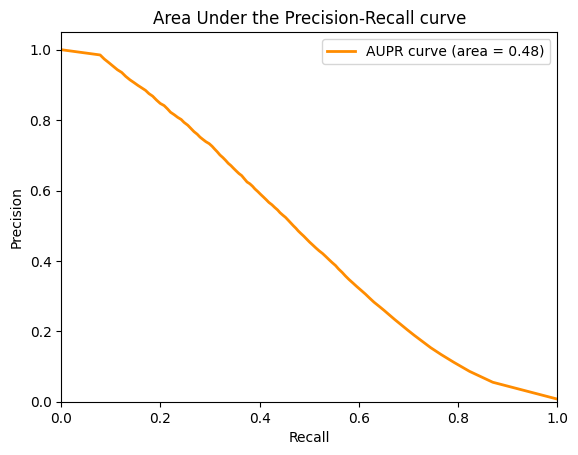

In [ ]:
from matplotlib import pyplot as plt

# Testing
def test_fun(X_test_new, Y_test_new):
    fmax, tmax = 0.0, 0.0
    precisions, recalls = [], []
    for t in range(0, 101, 1):
        #test_preds = model1.predict(X_test_new)
        test_preds = np.copy(X_test_new)

        threshold = t / 100.0
        #print("THRESHOLD IS =====> ", threshold)
        test_preds[test_preds>=threshold] = int(1)
        test_preds[test_preds<threshold] = int(0)

        rec = recall(Y_test_new, test_preds)
        pre = precision(Y_test_new, test_preds)
        if math.isnan(pre):
            pre = 1.0
        recalls.append(rec)
        precisions.append(pre)

        f = 2 * pre * rec / (pre + rec)
        #print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score1: {0}'.format(f*100))

        if fmax < f:
            fmax = f
            tmax = threshold

    test_preds = np.copy(X_test_new)
    print("THRESHOLD IS =====> ", tmax)
    test_preds[test_preds>=tmax] = int(1)
    test_preds[test_preds<tmax] = int(0)

    rec = recall(Y_test_new, test_preds)
    pre = precision(Y_test_new, test_preds)

    f = 2 * pre * rec / (pre + rec)
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score1: {0}'.format(f*100))

    # COMPUTE AUPR
    precisions = np.array(precisions)
    recalls = np.array(recalls)
    sorted_index = np.argsort(recalls)
    recalls = recalls[sorted_index]
    precisions = precisions[sorted_index]
    aupr = np.trapezoid(precisions, recalls)
    print(f'AUPR: {aupr:0.3f}')

    plt.figure()
    plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'AUPR curve (area = {aupr:0.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Area Under the Precision-Recall curve')
    plt.legend(loc="upper right")
    plt.savefig(f'aupr.pdf')

    return tmax

th_set = test_fun(X_test_new, Y_test_new)

AUROC: 0.911


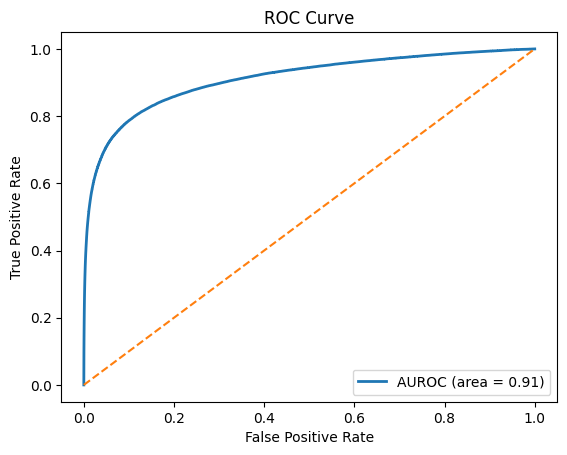

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# Flatten if multilabel
y_true = Y_test_new.flatten()
y_scores = X_test_new.flatten()   # RAW predictions (no threshold)

# AUROC
auroc = roc_auc_score(y_true, y_scores)
print(f'AUROC: {auroc:.3f}')

fprs, tprs, _ = roc_curve(y_true, y_scores)

plt.figure()
plt.plot(fprs, tprs, lw=2, label=f'AUROC (area = {auroc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.savefig('auroc.pdf')